# Imaging with AMI, part 1: simulating DISCO data from an image

Before reconstructing images from aperture-masking data, we need to be sure we can *simulate* such data from a known image. This tutorial does that for JWST/NIRISS AMI data as processed by AMIGO, whose products are "mixed DISCO" coefficients: linear combinations of the log-amplitudes and phases of the complex visibilities, with independent errors.

Real DISCO products are large, so we use `drpangloss.amigo.simulated_disco_record`, a small record with the same structure. Its uv samples fill a half-plane of a regular lattice out to 6.5 m, rotated on the sky as AMI data are by the parallactic angle. Its modes are the log-amplitudes, plus combinations of the phases that do not respond to a shift of the source, like kernel phases. Every mode has an error of 1e-4, typical of the ν Hor observations. Everything below is simulated.

4.80 um, 156 uv points
longest baseline 6.5 m, finest fringes 152 mas
uv lattice rotated by -6.9 deg


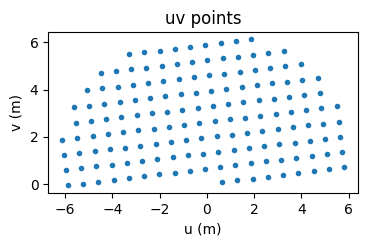

In [1]:
import sys
import time
from pathlib import Path

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from drpangloss._geometry import pixel_offsets
from drpangloss.amigo import simulated_disco_record
from drpangloss.models import BinaryModelCartesian, Image, PointSource, System
from drpangloss.oidata import OIData
from drpangloss.plotting import plot_model
from drpangloss.scenes import ring, spiral

template = OIData(simulated_disco_record(wavelength_m=4.8e-6, rotation_deg=-6.9))
longest = float(jnp.hypot(template.u, template.v).max())
fringe_mas = 206265e3 * float(template.wavel) / longest
print(f"{1e6 * float(template.wavel):.2f} um, {template.u.size} uv points")
print(f"longest baseline {longest:.1f} m, finest fringes {fringe_mas:.0f} mas")
print(f"uv lattice rotated by {template.uv_grid.rotation_deg:.1f} deg")

fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(template.u, template.v, ".")
ax.set(xlabel="u (m)", ylabel="v (m)", title="uv points", aspect="equal")
plt.show()

The samples are a lattice rotated by the parallactic angle. drpangloss finds the lattice when the data are loaded (`template.uv_grid`); we will use it at the end.

## The truth scene

At 4.8 µm the finest fringes have a period of about 150 mas, so structure on a few hundred milliarcseconds is well resolved, and pixels of 10 mas are fine enough. Our truth is a dusty spiral in the style of the "pinwheel" nebulae of WR 104 and WR 137, around an unresolved star.

`drpangloss.scenes.spiral` returns a unit-sum image in the drpangloss orientation (East left, North up). `Image.from_brightness` turns it into a model component whose pixels are the free parameters of an imaging fit. Like every component, it carries a `flux` relative to the others in a `System`: here the dust has 5% of the star's flux.

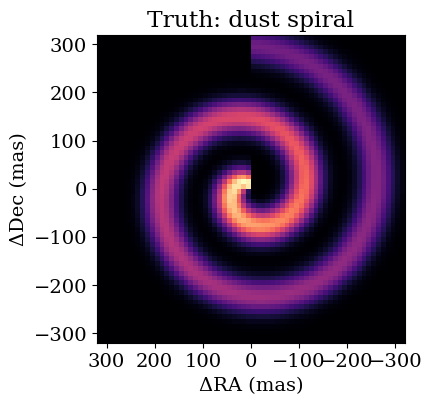

In [2]:
npix, pixel_scale = 64, 10.0  # 640 mas field of view
truth = spiral(
    npix,
    pixel_scale,
    step_mas=150.0,
    width_mas=25.0,
    turns=2.0,
    fade_mas=250.0,
)
scene = System(
    star=PointSource(),
    dust=Image.from_brightness(truth, pixel_scale, flux=0.05),
)

plot_model(
    scene.dust,
    fov_mas=npix * pixel_scale,
    npix=npix,
    title="Truth: dust spiral",
)
plt.show()

## Simulating noisy data

`OIData.with_model` evaluates a model at the uv points of an existing data object, adds Gaussian noise with that object's error bars, and keeps the DISCO operators. The key makes the noise reproducible.

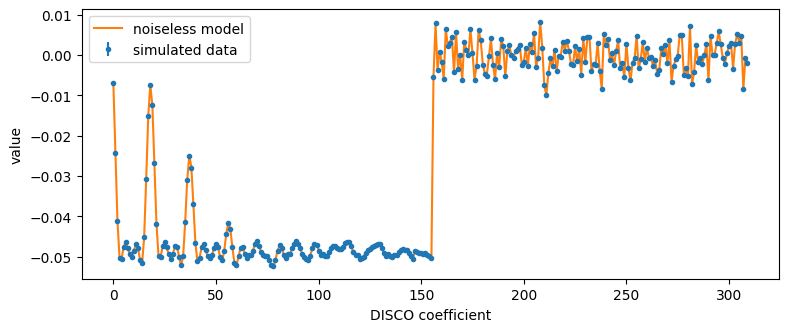

chi^2 of the truth: 338 for 310 coefficients


In [3]:
simulated = template.with_model(scene, key=jax.random.PRNGKey(0))
data, errors = simulated.flatten_data()
prediction = simulated.model(scene)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(prediction, "-", color="C1", label="noiseless model")
ax.errorbar(
    range(data.size), data, errors, fmt=".", color="C0", label="simulated data"
)
ax.set(xlabel="DISCO coefficient", ylabel="value")
ax.legend()
plt.show()

chi2 = jnp.sum(((data - prediction) / errors) ** 2)
print(f"chi^2 of the truth: {chi2:.0f} for {data.size} coefficients")

The first coefficients are the log-amplitudes and the rest are shift-invariant phase combinations. The data scatter around the model within their error bars, and the chi-squared of the truth is comparable to the number of coefficients, as it should be.

## Check: one bright pixel is a binary

A good test of a pixelised model is a case with a known answer. An `Image` with all of its flux in a single pixel is a point source at that pixel's offset, so inside a `System` with a star it must agree with the analytic `BinaryModelCartesian`. Row 20 is North of the image centre and column 40 is West of it, so `pixel_offsets` gives the offset with East and North positive.

In [4]:
row, col = 20, 40
offsets = pixel_offsets(npix, pixel_scale)
one_pixel = jnp.full((npix, npix), -jnp.inf).at[row, col].set(0.0)

pixels = System(
    star=PointSource(), companion=Image(one_pixel, pixel_scale, flux=0.05)
)
binary = BinaryModelCartesian(dra=offsets[col], ddec=offsets[row], flux=0.05)

difference = jnp.abs(template.model(pixels) - template.model(binary))
print(
    f"companion at dRA = {offsets[col]:.0f} mas, dDec = {offsets[row]:.0f} mas"
)
print(f"largest difference in the DISCO observables: {difference.max():.1e}")
print(f"largest observable: {jnp.abs(template.model(binary)).max():.1e}")

companion at dRA = -85 mas, dDec = 115 mas
largest difference in the DISCO observables: 1.2e-07
largest observable: 1.0e-01


The two agree to float32 rounding, so the image and the analytic model are interchangeable in the likelihood.

## Pixels that follow the detector

The visibilities of an `Image` are an exact sum over its pixels, whatever the uv sampling. When the samples lie on a lattice, and the image's pixel grid is rotated to match it (`rotation_deg`), the sum separates into two small matrix products, the matrix Fourier transform of Soummer et al. (2007). That is much faster and gives the same answer. For AMI this means pixels aligned with the detector rather than with North; `render` and `plot_model` still show the image North up.

In [5]:
rotation = template.uv_grid.rotation_deg
detector_dust = Image.from_model(
    scene.dust, npix, pixel_scale, flux=0.05, rotation_deg=rotation
)
detector_scene = System(star=PointSource(), dust=detector_dust)
per_point = eqx.tree_at(
    lambda d: d.uv_grid, template, None, is_leaf=lambda x: x is None
)

evaluate = eqx.filter_jit(lambda data_object, model: data_object.model(model))
for name, data_object in [("lattice (MFT)", template), ("per point", per_point)]:
    evaluate(data_object, detector_scene).block_until_ready()
    start = time.perf_counter()
    for _ in range(100):
        evaluate(data_object, detector_scene).block_until_ready()
    print(f"{name}: {10 * (time.perf_counter() - start):.2f} ms per evaluation")

difference = jnp.abs(template.model(detector_scene) - per_point.model(detector_scene))
print(f"largest difference: {difference.max():.1e}")

lattice (MFT): 0.07 ms per evaluation
per point: 0.16 ms per evaluation


largest difference: 6.3e-08


## Another scene: a lopsided ring

`drpangloss.scenes` also has an inclined ring with one brighter side, and a Gaussian blob for clumps or companions. Position angles are measured from North towards East, so the brightest part of this ring, at position angle 90 degrees, lies to the left of the image.

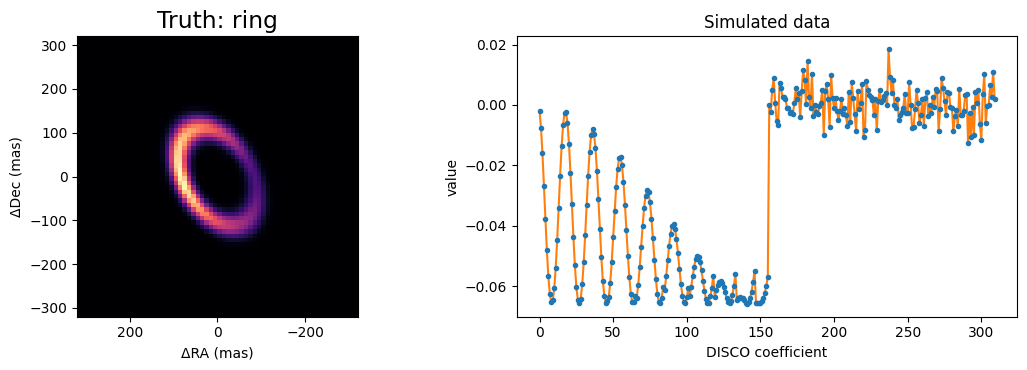

In [6]:
ring_image = ring(
    npix,
    pixel_scale,
    radius_mas=120.0,
    width_mas=20.0,
    inc_deg=50.0,
    pa_deg=30.0,
    asymmetry=0.6,
    asymmetry_pa_deg=90.0,
)
ring_scene = System(
    star=PointSource(),
    dust=Image.from_brightness(ring_image, pixel_scale, flux=0.05),
)
ring_data = template.with_model(ring_scene, key=jax.random.PRNGKey(1))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
plot_model(
    ring_scene.dust,
    fov_mas=npix * pixel_scale,
    npix=npix,
    ax=axes[0],
    title="Truth: ring",
)
d, e = ring_data.flatten_data()
axes[1].plot(ring_data.model(ring_scene), "-", color="C1")
axes[1].errorbar(range(d.size), d, e, fmt=".", color="C0")
axes[1].set(xlabel="DISCO coefficient", ylabel="value", title="Simulated data")
plt.tight_layout()
plt.show()

## Next steps

We now have simulated data and a truth to compare against. The next parts reconstruct the image from data like these, starting from a parametric fit and moving to free pixels with regularisation.